In [1]:
import sys
import importlib
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import RandomizedSearchCV
from utils.model_classes import XGBModel

PROJECT_ROOT = Path().resolve().parent.parent.parent
print(f"Project root: {PROJECT_ROOT}")

INITIAL_FEATURES_PATH = PROJECT_ROOT / 'data' / 'normal_features'
TRAIN_PATH = INITIAL_FEATURES_PATH / 'train.parquet'
VAL_PATH = INITIAL_FEATURES_PATH / 'val.parquet'
TEST_PATH = INITIAL_FEATURES_PATH / 'test.parquet'

MODEL_SAVE_PATH = PROJECT_ROOT / 'Models'

RANDOM_STATE = 42

import torch
# Detect device: 'cuda' if available, else 'cpu'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

# for parallelization
N_JOBS = -1

Using device: cuda
Project root: /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_bech/primaverile/M-P6203E-DataProjects-Hackaton3_P1
Using device: cuda


# XGBoost Model - on initial features
By leveraging initial metadata-derived features, this notebook treats citation prediction as a supervised binary classification task.

To ensure code quality and reusability, we use the shared model hierarchy:

- `BaseModel`: an abstract class that defines the common contract for preprocessing, training, prediction, evaluation, and saving.
- `XGBModel`: the concrete XGBoost implementation. It drops non-feature columns, applies `RobustScaler` consistently across splits, and trains a gradient-boosted tree classifier.


## 1. Load initial feature data

In [2]:
# splitting
df_train = pd.read_parquet(TRAIN_PATH)
df_val = pd.read_parquet(VAL_PATH)
df_test = pd.read_parquet(TEST_PATH)

ID_COLUMNS = ["article_id", "ref_id"]
df_train = df_train.drop(columns=ID_COLUMNS, errors="ignore")
df_val = df_val.drop(columns=ID_COLUMNS, errors="ignore")
df_test = df_test.drop(columns=ID_COLUMNS, errors="ignore")

print("\nSplit sizes:", {"train": len(df_train), "test": len(df_test), "val": len(df_val)})


Split sizes: {'train': 2162520, 'test': 396382, 'val': 391242}


## 2. Baseline model

[XGB_baseline] Preprocessing 2162520 rows...
Label distribution:
is_reference_valid
1    0.5
0    0.5
Name: proportion, dtype: float64
[XGB_baseline] Starting training...
Selected 21625/2162520
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      8935
           1     1.0000    1.0000    1.0000     12690

    accuracy                         1.0000     21625
   macro avg     1.0000    1.0000    1.0000     21625
weighted avg     1.0000    1.0000    1.0000     21625



/home/tommaso/miniconda3/envs/hack_03/lib/python3.11/site-packages/xgboost/core.py:751: UserWarning: [10:43:25] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125072520/work/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


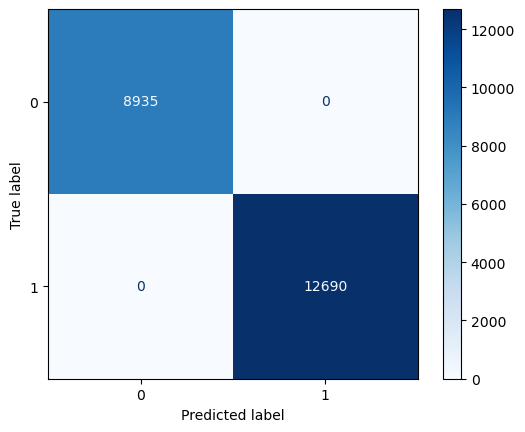

In [3]:
XGB_baseline = XGBModel('XGB_baseline', tree_method="hist")
XGB_baseline.train_pipeline(df_train, random_state=RANDOM_STATE)

> The confusion matrix for the training set shows an accuracy of 100%. This indicates severe overfitting, which is most likely to happen for high-capacity models like XGBoost that can easily memorize the pattern of the training set, but completely fail to generalize for unseen data.

[XGB_baseline] Preprocessing 396382 rows...
Label distribution:
is_reference_valid
1    0.5
0    0.5
Name: proportion, dtype: float64
              precision    recall  f1-score   support

           0     0.5330    0.8675    0.6603    198191
           1     0.6441    0.2398    0.3495    198191

    accuracy                         0.5537    396382
   macro avg     0.5885    0.5537    0.5049    396382
weighted avg     0.5885    0.5537    0.5049    396382



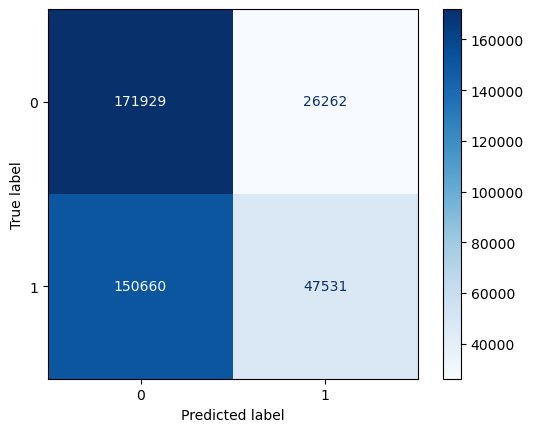

In [4]:
XGB_baseline.test_pipeline(df_test)

> The model's accuracy drops to 55.37% for unseen data, the confusion matrix shows that the model is lightly better in identifying papers that don't have references. From the errors, we can see that the model absolutely need to have the hyperparameters tuned to improve generalization.

## 3. Hyperparameter tuning
Because XGBoost exposes many interacting hyperparameters, an exhaustive grid search would be too expensive on the full dataset. The notebook therefore uses `RandomizedSearchCV`, which samples a fixed number of configurations from the defined parameter distributions.

This approach explores learning rate, tree depth, sampling, and regularization options efficiently while keeping the tuning run manageable on large feature matrices.


In [5]:
# Valid hyperparameters for XGBClassifier
param_dist = {
    "n_estimators": [100, 200, 500],
    "max_depth": [3, 6, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_lambda": [1, 5, 10],
    "scale_pos_weight": [1, 2, 5],
}

[XGB_initial] Grid Search...
[XGB_initial] Preprocessing 2162520 rows...
Label distribution:
is_reference_valid
1    0.5
0    0.5
Name: proportion, dtype: float64
[XGB_initial] Preprocessing 391242 rows...
Label distribution:
is_reference_valid
1    0.5
0    0.5
Name: proportion, dtype: float64
[XGB_initial] CUDA detected: using n_jobs=1 for RandomizedSearchCV to avoid running multiple GPU fits at the same time.
Fitting 2 folds for each of 20 candidates, totalling 40 fits
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=10, n_estimators=100, reg_lambda=5, scale_pos_weight=5, subsample=1.0; total time=   1.6s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=10, n_estimators=100, reg_lambda=5, scale_pos_weight=5, subsample=1.0; total time=   1.5s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=6, n_estimators=100, reg_lambda=10, scale_pos_weight=5, subsample=0.8; total time=   1.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=6, n_esti

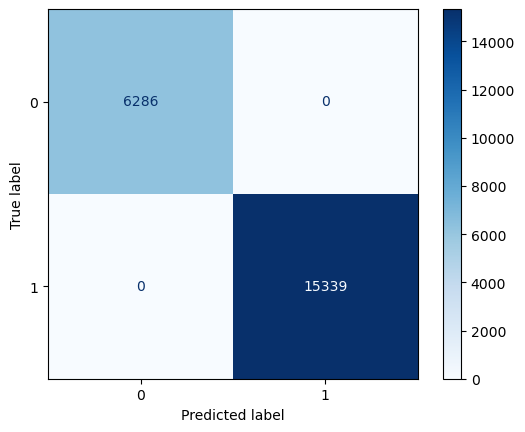

In [6]:
# tuning
XGB_initial = XGBModel("XGB_initial", tree_method="hist")
XGB_initial.hypertune_pipeline(df_train, df_val, param_dist, 
                            n_iter=20,
                            cv=2,
                            scoring="f1",
                            random_state=RANDOM_STATE,
                            n_jobs=N_JOBS,
                            pre_dispatch=N_JOBS,
                            error_score="raise",
                            verbose=2,
                        )

## 4. Final model with best parameters
Once the best XGBoost configuration is selected, the estimator is retrained through the shared training pipeline and evaluated on the held-out test split.

Performance is assessed using:
- Weighted F1-score, to summarize class-balanced performance.
- Confusion matrix, to visualize false positives and false negatives.
- Classification report, with precision, recall, F1-score, and accuracy.


[XGB_initial] Preprocessing 396382 rows...
Label distribution:
is_reference_valid
1    0.5
0    0.5
Name: proportion, dtype: float64
              precision    recall  f1-score   support

           0     0.5785    0.6193    0.5982    198191
           1     0.5904    0.5487    0.5688    198191

    accuracy                         0.5840    396382
   macro avg     0.5844    0.5840    0.5835    396382
weighted avg     0.5844    0.5840    0.5835    396382



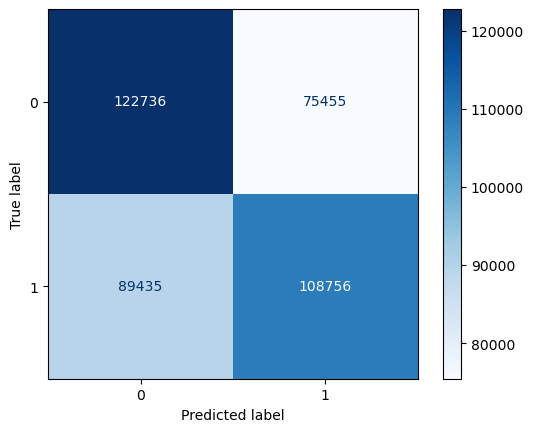

In [7]:
XGB_initial.test_pipeline(df_test)

> After performing a Grid Search, the accuracy slightly increased to 58.40%. The confusion matrix shows that the model decreased the number of False negatives, making the model slightly better in identifying true labels.

## 5. Save the pretrained model
Finally, the trained model is saved with the custom `save_model_artifact` utility, so it can be reused for later evaluation, explainability, or deployment experiments.


In [8]:
from utils.model_saver import save_model_artifact

save_model_artifact(XGB_initial, df_name='initial_features', 
                    model_name="Best_XGB_initial_based", 
                    relative_model_dir=MODEL_SAVE_PATH)